# `bfs` — BFS 알고리즘 데모

[`algorithms/graph/bfs.py`](bfs.py) 는 textbook iterative BFS — `("visit", u, level)` 이벤트를 yield 한다. queue 에 level 저장, push 시점 visited 마킹.

[`algorithms/graph/trace.py`](trace.py) 의 `@trace` 데코레이터가 `bfs.visits` · `bfs.levels` helper 를 자동 부여한다. 별도 `bfs_levels` 함수 · `TreeEdge` 역추정 불필요.

In [33]:
import sys

sys.path.insert(0, '../..')

import core.graph as g
from algorithms.graph.bfs import bfs

a, b, c, d, e, f = g.vertices('a', 'b', 'c', 'd', 'e', 'f')

def show(graph, start):
    """원본 그래프 위에 BFS level 그룹들을 색깔별로 강조."""
    return graph._to_graphviz(highlight=bfs.levels(graph, start))

## 0. textbook 사용법

`bfs(g, a)` — `("visit", u, level)` 이벤트 iterator. `bfs.visits(g, a)` 로 정점 list만 출력.

In [34]:
g3 = g.UnweightedGraph()
for u, v in [(a, b), (a, c), (b, d), (b, e), (c, f)]:
    g3.add_edge(u, v)

for u in bfs.visits(g3, a):
    print(u)

a
b
c
d
e
f


## 1. Path — `a-b-c-d`

선형 → 4개 level (각 정점이 별도 level).

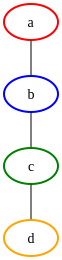

In [35]:
show(g.Graph(a - b - c - d), a)

## 2. Cycle — `a-b-c-a`

Level 0: `a`, level 1: `b, c`. 2색.

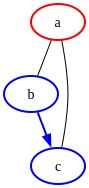

In [36]:
show(g.Graph(a - b - c - a), a)

## 3. Tree (분기)

Level 별로 묶임: `a` (빨강), `b/c` (파랑), `d/e/f` (초록). 같은 level 정점 간 ghost edge 가 점선으로 그려짐.

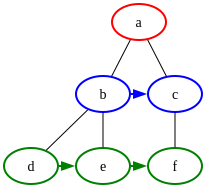

In [37]:
show(g3, a)

## 4. K4 — 완전 그래프

Level 0: `a`, level 1: `b, c, d`. 2색.

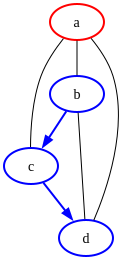

In [38]:
show(g.Graph.complete(a, b, c, d), a)

## 5. Directed — `a → b → c, a → c`

`a→c` 직통이 있어도 BFS 는 `a→b→c` 와 같은 level 1 로 도달. Level 0: `a`, level 1: `b, c`.

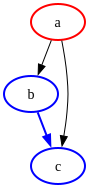

In [39]:
g5 = g.UnweightedGraph(kind=g.EdgeKind.DIRECTED)
for u, v in [(a, b), (b, c), (a, c)]:
    g5.add_edge(u, v)

show(g5, a)

## 6. 고립 정점

Level 0 만 존재 → 단일 정점 graph 1개.

groups: [UnweightedGraph(undirected, V=1, E=0)]


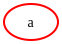

In [40]:
g6 = g.UnweightedGraph()
g6.add_vertex(a)

print('groups:', bfs.levels(g6, a))
show(g6, a)

## 7. 큰 격자 — `5×5` grid

BFS 의 동심원 전파 패턴이 가장 잘 드러나는 예시.

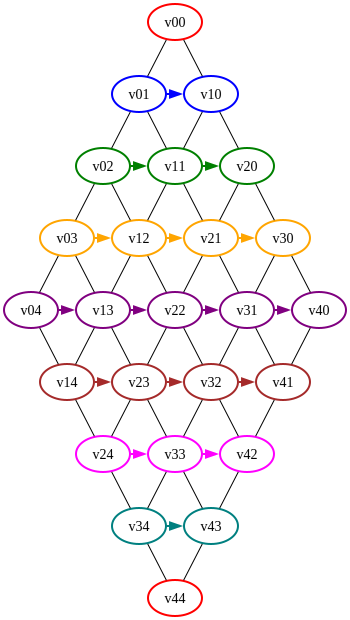

In [41]:
grid = g.Graph.grid(5, 5)
show(grid, grid.get_vertex('v00'))

## 8. Petersen graph

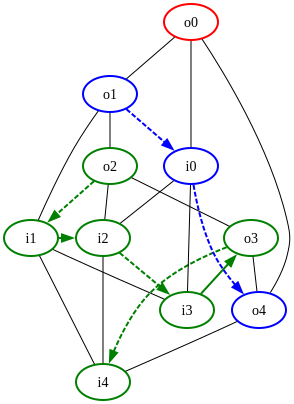

In [42]:
pet = g.Graph.petersen()
show(pet, pet.vertices()[0])

## 9. raw 이벤트 스트림

`bfs(g, a)` 직접 소비 — `("visit", u, level)` 이벤트 출력. level 순서로 정점이 나온다.

In [43]:
for event in bfs(g3, a):
    match event:
        case ("visit", u, level):
            print(f"  level {level}  visit {u}")